In [1]:
import pandas as pd

# Load transformed data (already preprocessed)
df_model = pd.read_csv("prep_outputs/final_transformed_table_selected.csv")

print(df_model.shape)
print(df_model.head())

(25403, 85)
   RID  AMIGR  AGE_BAND_30-44  AGE_BAND_45-59  AGE_BAND_60+     AGE_P  \
0    1      2             0.0             0.0           1.0  1.489521   
1    2      1             1.0             0.0           0.0 -0.800814   
2    3      2             0.0             0.0           0.0 -1.237069   
3    4      1             0.0             0.0           1.0  1.271394   
4    5      2             1.0             0.0           0.0 -0.691751   

   AHAYFYR_2  AHCSYR1_2  ANX_1_2  ANX_1_5  ...  SMKSTAT2_4  TIRED_1_2  \
0        1.0        1.0      0.0      0.0  ...         0.0        0.0   
1        1.0        1.0      0.0      0.0  ...         1.0        1.0   
2        1.0        1.0      0.0      1.0  ...         1.0        1.0   
3        1.0        1.0      0.0      0.0  ...         0.0        1.0   
4        1.0        1.0      1.0      0.0  ...         1.0        0.0   

   TIRED_1_3  TIRED_1_4  TIRED_2_2  TIRED_2_3  TIRED_3_2    WKDAYR  \
0        0.0        0.0        0.0      

Logistic Regression: mean AUC = 0.810 ± 0.011
Decision Tree: mean AUC = 0.770 ± 0.012
Random Forest: mean AUC = 0.795 ± 0.009


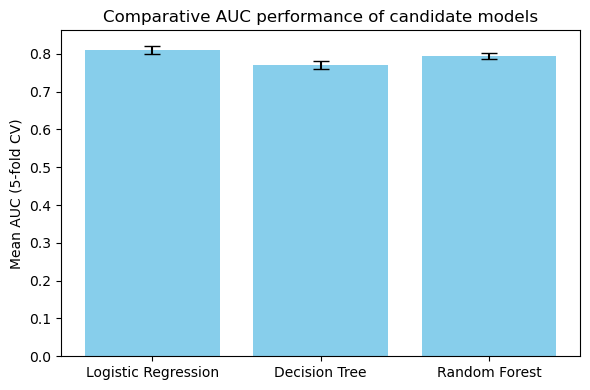

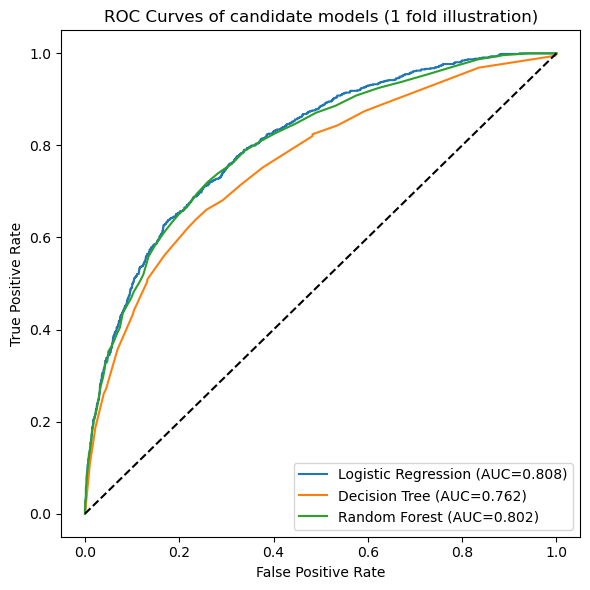

In [2]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) Prepare features and target
# -----------------------------
X = df_model.drop(columns=["RID", "AMIGR"])
y = df_model["AMIGR"].map({1:1, 2:0})   # convert to binary 0/1

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced")
}

# -----------------------------
# 2) Cross-validation AUC results
# -----------------------------
mean_scores, std_scores = {}, {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    mean_scores[name] = scores.mean()
    std_scores[name] = scores.std()
    print(f"{name}: mean AUC = {scores.mean():.3f} ± {scores.std():.3f}")

# -----------------------------
# 3) Plot bar chart with error bars
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(mean_scores.keys(), mean_scores.values(), yerr=std_scores.values(), capsize=6, color="skyblue")
plt.ylabel("Mean AUC (5-fold CV)")
plt.title("Comparative AUC performance of candidate models")
plt.tight_layout()
plt.savefig("figs/fig_6_1_model_auc.png", dpi=200)
plt.show()

# -----------------------------
# 4) ROC Curves 
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plt.figure(figsize=(6,6))

for name, model in models.items():
    # Use first fold to illustrate ROC curve
    train_idx, test_idx = next(cv.split(X, y))
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = model.predict_proba(X.iloc[test_idx])[:,1]
    fpr, tpr, _ = roc_curve(y.iloc[test_idx], y_prob)
    auc = roc_auc_score(y.iloc[test_idx], y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of candidate models (1 fold illustration)")
plt.legend()
plt.tight_layout()
plt.savefig("figs/fig_6_2_roc.png", dpi=200)
plt.show()